# Does the orthogonal identifiability ambiguity survive action-conditioning?

**A controlled, ground-truth experiment on LeJEPA-style latent recovery in an action-conditioned world.**

Author: **Sid Ahmed Bouamama**

---

**Abstract.** LeJEPA-style self-supervised training provably recovers the latent state of a
Gaussian world *up to an orthogonal transformation* — but the existing guarantee covers only the
symmetric, action-free case. Separately, V-JEPA 2, an action-conditioned latent world model, was
observed empirically to recover its action axis up to a near-rotation (reported condition number
≈ 1.5). This notebook tests directly whether the orthogonal ambiguity survives the passage to the
action-conditioned regime, in a synthetic world where we own the ground truth: the latents, the
dynamics $(\rho, B)$, and the observation map. We train a LeJEPA-style encoder with an
action-conditioned linear predictor — SIGReg for collapse prevention, no teacher–student, no
stop-gradient — and measure (M1) state recovery up to rotation via orthogonal Procrustes, (M2) the
action axis up to rotation via the condition number of the alignment residual map (the headline
number, directly comparable to V-JEPA 2's ≈ 1.5), and (M3) recovery of the dynamics in closed form.
All metrics are computed on a held-out split, across ablations (observation nonlinearity, SIGReg
on/off, symmetric vs. action-conditioned, action excitation, dimensions) with multiple training
seeds per condition. **Both outcomes are a result**: near-orthogonal recovery (condition number
near 1) confirms that the identifiability picture extends empirically to action-conditioning;
distortion beyond a rotation means identifiability is more fragile under action-conditioning,
which sharpens the open problem — and is reported just as plainly.


## 1. Background and hypothesis

**LeJEPA.** Joint-embedding predictive architectures (JEPAs) learn by making the embedding of one
view predictable from the embedding of another. Unconstrained, this objective collapses (a constant
encoder predicts itself perfectly). LeJEPA (Balestriero & LeCun, 2025) replaces the usual
anti-collapse heuristics — EMA target encoders, stop-gradients, whitening layers — with a single
statistical regularizer, **SIGReg** (Sketched Isotropic Gaussian Regularization), which pushes the
embedding distribution toward an isotropic Gaussian $\mathcal{N}(0, I_K)$. The target is not an
aesthetic choice: LeJEPA argues the isotropic Gaussian is the embedding law that minimizes
worst-case downstream prediction risk. The recipe is heuristic-free: one loss, one trade-off
parameter $\lambda$, no teacher–student asymmetry.

**Identifiability — the symmetric case.** A 2026 result by Klindt, LeCun & Balestriero proves
that in a Gaussian world — latents $z$ with stationary additive-noise (Ornstein–Uhlenbeck)
transitions, observed through a nonlinear map $x = g(z)$ — LeJEPA-style training recovers the true
latents **up to an orthogonal transformation** (rotation/reflection) and recovers the dynamics in
closed form. The orthogonal ambiguity is intrinsic: $\mathcal{N}(0, I)$ is rotation-invariant, so
if an encoder $f$ recovers $z$ exactly, then $O \circ f$ for any orthogonal $O$ (with the predictor
conjugated accordingly) attains exactly the same loss. No objective of this form can see the
rotation; the theorem's content is that *nothing more than the rotation is lost*. Crucially, the
guarantee covers the state and the **symmetric (no-action) case only**.

**The action-conditioned echo.** V-JEPA 2 (Assran et al., 2025) is an action-conditioned latent
world model trained at scale. Empirically, it was observed to recover its action axis up to a
near-rotation: the linear map aligning learned and true action effects had a reported condition
number around **1.5** (a condition number of exactly 1 means a scaled rotation).

**The open question.** Does the orthogonal ambiguity of the identifiability guarantee survive the
passage to the action-conditioned regime? Nobody has proven it; V-JEPA 2 is a single, uncontrolled
data point at scale. Here we test it in a minimal synthetic world where the ground truth is known
exactly.

**Falsifiable hypothesis.** Training an action-conditioned LeJEPA model on a world satisfying the
Gaussian assumptions recovers (a) the state up to rotation — orthogonal-Procrustes $R^2$ close to
unrestricted-linear $R^2$, both high; (b) the action effect $B$ up to the *same* rotation —
condition number of the residual alignment map near 1; and (c) the dynamics $(\rho, B)$ in closed
form. **Two outcomes, both results:**

- *Confirmed*: recovery stays orthogonal (condition number near 1, in the same regime as
  V-JEPA 2's ≈ 1.5). The identifiability picture extends empirically to action-conditioning.
- *Broken*: recovery is distorted beyond a rotation (large condition number, or a large gap between
  linear and orthogonal $R^2$). Identifiability is more fragile under action-conditioning — a
  sharper open problem, reported honestly.


## 2. Setup: reproducibility and the QUICK toggle

Every random quantity in this notebook is seeded, and two kinds of seed are kept strictly separate:

- **World seed** (fixed once, default 1234): generates the ground truth — the action-effect matrix
  $B$, the frozen observation map $g$, its calibration sample, and the data rollouts. The world is
  *the same* for every training run, so runs are compared on identical data.
- **Training seeds** (varied: 0–4): control encoder/predictor initialization and batch shuffling
  only. The seed-to-seed spread therefore measures *training stochasticity*, not data resampling.

`QUICK` toggle: when `True`, tiny dimensions, few steps, 2 seeds and a reduced ablation grid — the
whole notebook runs in well under a minute on CPU, as a correctness check of every code path
(figures, CSV, verdict included). When `False`, the full settings from the experiment spec
(5 seeds × 18 conditions; minutes on a V100, around 1–2 hours on a laptop CPU). QUICK results are
**never** scientific results, and the final verdict cell says so loudly when QUICK is on.

Headless execution (used for verification) runs the same notebook top-to-bottom:

```bash
LEJEPA_QUICK=1 python tools/run_notebook.py lejepa_action_identifiability.ipynb --out executed.ipynb
```

Determinism: exact on CPU (`torch.use_deterministic_algorithms(True, warn_only=True)`); best-effort
on CUDA/MPS. Conclusions never rest on bitwise reproducibility — they rest on mean ± std across
training seeds.


In [1]:
# -- driver (notebook-only) --
# Install any missing dependency, then do nothing on subsequent runs. Uses
# subprocess rather than %pip so the cell is plain Python (compile-checkable,
# runs identically under headless nbclient and interactive Jupyter).
import importlib.util
import subprocess
import sys

_needed = ["torch", "numpy", "pandas", "matplotlib"]
_missing = [p for p in _needed if importlib.util.find_spec(p) is None]
if _missing:
    print("Installing missing packages:", _missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_missing])
else:
    print("All dependencies present:", ", ".join(_needed))


All dependencies present: torch, numpy, pandas, matplotlib


In [2]:
# -- module: setup --
# Shared imports and utilities (Phase 2: common header of every src/ module).
import dataclasses
import math
import os
import shutil
import time
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib

# Same backend the `%matplotlib inline` magic would select, set explicitly so the
# notebook renders figures identically under interactive Jupyter and headless
# nbclient (falls back to Agg outside a kernel, e.g. after Phase-2 extraction).
try:
    matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

RESULTS_DIR = Path("results")
FIG_DIR = RESULTS_DIR / "figures"


def ensure_dirs():
    """Create results/ and results/figures/ (idempotent)."""
    FIG_DIR.mkdir(parents=True, exist_ok=True)


def pick_device():
    """cuda > mps > cpu; LEJEPA_DEVICE overrides (e.g. to benchmark cpu vs mps)."""
    forced = os.environ.get("LEJEPA_DEVICE", "")
    if forced:
        return torch.device(forced)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def set_seed(seed):
    """Seed every RNG that training touches. The synthetic world never uses the
    global RNGs (it draws from its own explicit torch.Generator), so calling
    this with a *training* seed cannot perturb the world -- the seed separation
    described in Section 2 is enforced structurally, not by discipline."""
    import random

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Exact determinism on CPU; warn-only on CUDA/MPS where some kernels
    # have no deterministic variant. Conclusions rest on multi-seed stats.
    torch.use_deterministic_algorithms(True, warn_only=True)


In [3]:
# -- module: setup --
@dataclass(frozen=True)
class Config:
    """Every knob of the experiment, in one frozen object.

    Defaults are the FULL-mode settings from the experiment spec. QUICK mode
    (make_config) shrinks dimensions/steps/seeds so the whole notebook runs in
    seconds as a smoke test. Ablations are dataclasses.replace()-modified
    copies of the base config, so every run's full configuration is logged.
    """

    quick: bool = False
    # ---- world (ground truth) ----
    n: int = 8                  # true latent dimension
    m: int = 2                  # action dimension
    rho: float = 0.9            # OU mean-reversion / state-transition scalar
    D: int = 64                 # observation dimension
    nonlinearity_strength: float = 1.0  # 0 = linear g, 1 = pure frozen MLP
    kappa: float = 0.5          # action signal fraction: lam_max(B Sigma_a B^T) / (1 - rho^2)
    action_scale: float = 1.0   # std of action components (excitation knob)
    action_rank: int = 0        # 0 = full-rank actions; r>0 = actions confined to r-dim subspace
    noise_mode: str = "balanced"  # "balanced" (z ~ N(0,I) exactly) | "literal" (spec's sqrt(1-rho^2) I noise)
    action_conditioned: bool = True  # False = symmetric control (B = 0, predictor ignores actions)
    world_seed: int = 1234
    n_train: int = 50_000
    n_eval: int = 10_000
    traj_len: int = 100         # transitions per trajectory (many short, independent chains)
    n_calib: int = 8192         # world-seed sample used to standardize the observation map
    # ---- model ----
    K: int = 8                  # embedding dimension (= n by default, comparable by orthogonal map)
    hidden: int = 256
    # ---- training ----
    steps: int = 4000
    warmup: int = 100
    batch_size: int = 512
    lr: float = 2e-3
    weight_decay: float = 0.01  # encoder weight matrices only (see Section 6 markdown)
    lam: float = 0.5            # SIGReg weight: L = (1-lam) L_pred + lam L_sigreg.
                                # 0.5, NOT the paper's 0.05: at toy scale the soft penalty
                                # at 0.05 sits at a partial-collapse equilibrium (dead
                                # embedding dims) -- measured by the lam=0.05 ablation;
                                # see the Section 6 markdown for the calibration argument.
    num_slices: int = 1024
    train_seeds: tuple = (0, 1, 2, 3, 4)


def make_config(quick):
    """Single derivation point for QUICK vs FULL. No other cell branches on QUICK."""
    if not quick:
        return Config(quick=False)
    return Config(
        quick=True,
        n=4, m=2, D=16, K=4, hidden=128,
        n_train=2_000, n_eval=500, traj_len=50, n_calib=2048,
        steps=150, warmup=15, batch_size=256, num_slices=128,
        train_seeds=(0, 1),
    )


In [4]:
# -- driver (notebook-only) --
QUICK = True  # <-- flip to False for the full run (the V100 / real-results setting)
# Headless override used by the verification harness; the literal above is what
# an interactive reader flips. If the env var is unset, the literal stands.
QUICK = bool(int(os.environ.get("LEJEPA_QUICK", "1" if QUICK else "0")))

CONFIG = make_config(QUICK)
DEVICE = pick_device()
ensure_dirs()

print(f"mode      : {'QUICK (smoke test -- not science)' if QUICK else 'FULL'}")
print(f"device    : {DEVICE}  (torch {torch.__version__})")
print(f"world seed: {CONFIG.world_seed}   training seeds: {CONFIG.train_seeds}")
print("config    :")
for k, v in asdict(CONFIG).items():
    print(f"    {k} = {v}")


mode      : QUICK (smoke test -- not science)
device    : mps  (torch 2.12.0)
world seed: 1234   training seeds: (0, 1)
config    :
    quick = True
    n = 4
    m = 2
    rho = 0.9
    D = 16
    nonlinearity_strength = 1.0
    kappa = 0.5
    action_scale = 1.0
    action_rank = 0
    noise_mode = balanced
    action_conditioned = True
    world_seed = 1234
    n_train = 2000
    n_eval = 500
    traj_len = 50
    n_calib = 2048
    K = 4
    hidden = 128
    steps = 150
    warmup = 15
    batch_size = 256
    lr = 0.002
    weight_decay = 0.01
    lam = 0.5
    num_slices = 128
    train_seeds = (0, 1)


## 3. The synthetic world (ground truth, frozen)

The world is built to satisfy the assumptions of the identifiability theory as exactly as
possible, so that any failure we observe is attributable to *action-conditioning*, not to a broken
assumption.

**Latent dynamics.** State $z_t \in \mathbb{R}^n$ ($n=8$), action $a_t \in \mathbb{R}^m$ ($m=2$),
sampled i.i.d. $a_t \sim \mathcal{N}(0, \Sigma_a)$ — the simplest form of the persistent-excitation
condition (exposed as a knob for the excitation ablation). The transition is linear-Gaussian:

$$z_{t+1} = \rho\, z_t + B a_t + \eta_t, \qquad \rho = 0.9 .$$

$B \in \mathbb{R}^{n \times m}$ is the **true action effect** — the ground-truth quantity the
headline metric (M2) compares against.

**A contradiction in the spec, and its resolution.** The spec asks for marginal
$z \sim \mathcal{N}(0, I_n)$ *and* transition noise $\eta \sim \mathcal{N}(0, (1-\rho^2) I)$. Both
cannot hold once $B \neq 0$: the stationary covariance solves the Lyapunov equation
$\Sigma = \rho^2 \Sigma + B \Sigma_a B^\top + \Sigma_\eta$, which for the literal noise gives

$$\Sigma_{\text{lit}} = I + \frac{B \Sigma_a B^\top}{1-\rho^2} \neq I .$$

This matters: SIGReg drives embeddings toward an *isotropic* Gaussian, so if the true latents are
anisotropic, even a **perfect** learner is forced to recover a whitened version
$\Sigma^{-1/2} z$ — injecting a condition-number artifact of exactly
$\mathrm{cond}(\Sigma_{\text{lit}}^{1/2})$ into the headline metric, for reasons that have nothing
to do with action-conditioning. We therefore resolve the contradiction in favor of the marginal
(the assumption that is load-bearing for the theory), using **balanced noise**:

$$\eta_t \sim \mathcal{N}(0, \Lambda), \qquad \Lambda = (1-\rho^2) I - B \Sigma_a B^\top ,$$

the unique Gaussian noise that makes $\mathcal{N}(0, I_n)$ *exactly* stationary (substitute into
the Lyapunov equation). Three consequences: (i) the chain is stationary from $t=0$, so no burn-in
is needed even at $\rho = 0.99$; (ii) when $B = 0$ it reduces *exactly* to the spec's OU world, so
the symmetric-vs-action comparison is apples-to-apples; (iii) the only change relative to the
proven symmetric setting is the action term — the cleanest possible test of the question.
Feasibility requires $\lambda_{\max}(B \Sigma_a B^\top) \le 1-\rho^2$ (asserted with margin). And
because this is a deviation from the spec's literal text, we keep a **`literal_noise` ablation
condition** that runs the spec's transition verbatim — so the whitening artifact is *measured*,
not assumed (its analytic prediction $\mathrm{cond}(\Sigma_{\text{lit}}^{1/2})$ is printed below).

**Drawing $B$ ("columns of moderate norm").** $B = b \cdot U$ with $U$ unit-norm Gaussian
direction columns and a single scalar $b$ calibrated so the **action signal fraction**
$\kappa = \lambda_{\max}(B \Sigma_a B^\top)/(1-\rho^2) = 0.5$ at base settings: along its strongest
direction, the action explains half of the one-step innovation variance. $\kappa$ is dimensionless
and $\rho$-portable, so the $\rho$-sensitivity cells do not secretly double as excitation cells.

**Observation map.** $x = g(z)$ with $g$ frozen (the world simulator, never trained):
$g_s = \mathrm{std}\big[(1-s)\,\tilde g_{\text{lin}} + s\,\tilde g_{\text{mlp}}\big]$, where
$g_{\text{lin}}$ is a random semi-orthogonal linear embedding $\mathbb{R}^n \to \mathbb{R}^D$
($D = 64$), $g_{\text{mlp}}$ is the spec's random MLP ($n \to 64 \to 64 \to D$, GELU), and $s$ is
the `nonlinearity_strength` knob. Each component — and then the mixture itself — is standardized
per output dimension on a world-seeded calibration sample (two stages, because the components are
correlated: a random MLP has a nonzero linear part). Every $s$ therefore produces observations
with per-dimension mean 0 / std 1, so the nonlinearity sweep varies *only* the nonlinearity, never
the input scale. For $D \gg n$, a random smooth map of this form is generically injective on
compact sets (stated as an assumption, not proven).

**Data.** Many short independent trajectories (length 100), giving 50k train / 10k held-out eval
tuples $(x_t, a_t, x_{t+1})$. The eval split keeps its true latents $z$ for metrics and is never
touched by training. Ground truth retained: $B$, $\rho$, $\Lambda$, $\Sigma_a$, the world seed,
and the eval-aligned latents.


In [5]:
# -- module: world --
class World:
    """Frozen synthetic world: ground-truth latent dynamics + observation map.

        z_{t+1} = rho * z_t + B a_t + eta_t        (latent, linear-Gaussian)
        x_t     = g(z_t)                           (frozen nonlinear observation)

    Everything random here is drawn from ONE explicit torch.Generator seeded with
    cfg.world_seed -- never from the global RNG -- so the world is bit-identical
    across training seeds and immune to set_seed() calls during training.

    noise_mode:
      "balanced": eta ~ N(0, Lambda), Lambda = (1-rho^2) I - B Sigma_a B^T.
          The unique Gaussian noise making N(0, I_n) *exactly* stationary
          (plug into Sigma = rho^2 Sigma + B Sigma_a B^T + Lambda).
          Reduces to the spec's OU noise when B = 0.
      "literal":  eta ~ N(0, (1-rho^2) I) exactly as written in the spec.
          Stationary marginal becomes N(0, Sigma_lit),
          Sigma_lit = I + B Sigma_a B^T / (1-rho^2)  (anisotropic).
          Kept as an ablation so the whitening artifact is measured, not assumed.

    In both modes z_0 is drawn from the exact stationary law, so rollouts need
    no burn-in and every tuple is an unbiased stationary sample.
    """

    def __init__(self, cfg):
        self.cfg = cfg
        n, m, rho = cfg.n, cfg.m, cfg.rho
        g = torch.Generator().manual_seed(cfg.world_seed)

        # ---- true action effect B = b * U (unit direction columns, common scale b) ----
        # b is calibrated so kappa = lam_max(B Sigma_a B^T)/(1-rho^2) at BASE settings
        # (action_scale=1, full rank): a dimensionless, rho-portable "moderate norm".
        Graw = torch.randn(n, m, generator=g)
        Udir = Graw / Graw.norm(dim=0, keepdim=True)
        lam_max_dir = float(torch.linalg.eigvalsh(Udir.T @ Udir).max())  # = lam_max(U U^T)
        self.b_scale = math.sqrt(cfg.kappa * (1.0 - rho**2) / lam_max_dir)
        if cfg.action_conditioned:
            self.B = self.b_scale * Udir
        else:
            self.B = torch.zeros(n, m)  # symmetric control: pure OU world
            # (Graw was still drawn above, so the generator state -- and hence the
            #  observation map g below -- is identical to the action-conditioned world.)

        # ---- action distribution: a = Vr c, c ~ N(0, action_scale^2 I_r) ----
        r = cfg.action_rank if cfg.action_rank > 0 else m
        Vr_raw = torch.randn(m, r, generator=g)  # drawn in all cases (RNG alignment)
        if r < m:
            self.Vr, _ = torch.linalg.qr(Vr_raw)  # m x r orthonormal: rank-deficient excitation
        else:
            self.Vr = torch.eye(m)
        self.action_rank = r
        Sigma_a = cfg.action_scale**2 * (self.Vr @ self.Vr.T)

        # ---- transition noise (see class docstring) ----
        BSB = self.B @ Sigma_a @ self.B.T
        evals, evecs = torch.linalg.eigh(BSB)
        if cfg.noise_mode == "balanced":
            assert float(evals.max()) <= 0.95 * (1.0 - rho**2) + 1e-9, (
                "infeasible world: action variance exceeds the innovation budget; "
                "lower kappa or action_scale")
            lam_sqrt = torch.sqrt(torch.clamp((1.0 - rho**2) - evals, min=0.0))
            self.noise_chol = evecs @ torch.diag(lam_sqrt) @ evecs.T  # Lambda^{1/2} (symmetric)
            self.Sigma = torch.eye(n)                                  # exact stationary cov
        elif cfg.noise_mode == "literal":
            self.noise_chol = math.sqrt(1.0 - rho**2) * torch.eye(n)
            self.Sigma = torch.eye(n) + BSB / (1.0 - rho**2)
        else:
            raise ValueError(f"unknown noise_mode {cfg.noise_mode!r}")
        sevals, sevecs = torch.linalg.eigh(self.Sigma)
        self.Sigma_sqrt = sevecs @ torch.diag(torch.sqrt(torch.clamp(sevals, min=0.0))) @ sevecs.T
        # Analytic whitening artifact IF the literal-noise world were used with this B:
        # cond(Sigma_lit^{1/2}). For the literal ablation this predicts the M2 inflation;
        # for balanced worlds it is the counterfactual being avoided.
        lit_evals = torch.linalg.eigvalsh(torch.eye(n) + BSB / (1.0 - rho**2))
        self.analytic_whiten_cond = float(torch.sqrt(lit_evals.max() / lit_evals.min()))

        # ---- frozen observation map g_s = std[(1-s) g~_lin + s g~_mlp] ----
        Wbig = torch.randn(cfg.D, n, generator=g)
        self.W_lin, _ = torch.linalg.qr(Wbig)  # D x n semi-orthogonal: clean linear endpoint
        widths = [n, 64, 64, cfg.D]            # spec's MLP, weights frozen at creation
        self.mlp_weights = []
        for fan_in, fan_out in zip(widths[:-1], widths[1:]):
            Wl = torch.randn(fan_out, fan_in, generator=g) / math.sqrt(fan_in)
            bl = 0.1 * torch.randn(fan_out, generator=g)
            self.mlp_weights.append((Wl, bl))
        # Two-stage standardization on a world-seeded calibration sample: first each
        # endpoint, then the mixture (the endpoints are correlated, so the mixture's
        # variance depends on s; stage 2 makes every s give mean-0/std-1 outputs).
        Zc = torch.randn(cfg.n_calib, n, generator=g)
        lin, mlp = Zc @ self.W_lin.T, self._mlp_raw(Zc)
        self.mu_lin, self.sd_lin = lin.mean(0), lin.std(0).clamp_min(1e-6)
        self.mu_mlp, self.sd_mlp = mlp.mean(0), mlp.std(0).clamp_min(1e-6)
        s = cfg.nonlinearity_strength
        mix = (1 - s) * (lin - self.mu_lin) / self.sd_lin + s * (mlp - self.mu_mlp) / self.sd_mlp
        self.mu_mix, self.sd_mix = mix.mean(0), mix.std(0).clamp_min(1e-6)

    def _mlp_raw(self, z):
        h = z
        for i, (W, b) in enumerate(self.mlp_weights):
            h = h @ W.T + b
            if i < len(self.mlp_weights) - 1:
                h = F.gelu(h)
        return h

    @torch.no_grad()
    def observe(self, z):
        """x = g_s(z). Frozen: plain tensors, no parameters, no gradients."""
        s = self.cfg.nonlinearity_strength
        lin = (z @ self.W_lin.T - self.mu_lin) / self.sd_lin
        mlp = (self._mlp_raw(z) - self.mu_mlp) / self.sd_mlp
        return ((1 - s) * lin + s * mlp - self.mu_mix) / self.sd_mix

    def sample_actions(self, n_rows, g):
        c = self.cfg.action_scale * torch.randn(n_rows, self.action_rank, generator=g)
        return c @ self.Vr.T

    def rollout(self, n_tuples, seed):
        """Roll independent trajectories; return n_tuples of (x_t, a_t, x_{t+1})
        plus the aligned true latents (z_t, z_{t+1}) for metrics."""
        cfg = self.cfg
        g = torch.Generator().manual_seed(seed)
        L = cfg.traj_len
        n_traj = math.ceil(n_tuples / L)
        z = torch.randn(n_traj, cfg.n, generator=g) @ self.Sigma_sqrt.T  # exact stationary start
        Zt, At, Zt1 = [], [], []
        for _ in range(L):
            a = self.sample_actions(n_traj, g)
            eta = torch.randn(n_traj, cfg.n, generator=g) @ self.noise_chol.T
            z_next = cfg.rho * z + a @ self.B.T + eta
            Zt.append(z); At.append(a); Zt1.append(z_next)
            z = z_next
        # (L, n_traj, .) -> trajectory-major -> first n_tuples rows
        z_t = torch.stack(Zt).transpose(0, 1).reshape(n_traj * L, cfg.n)[:n_tuples]
        a_t = torch.stack(At).transpose(0, 1).reshape(n_traj * L, cfg.m)[:n_tuples]
        z_t1 = torch.stack(Zt1).transpose(0, 1).reshape(n_traj * L, cfg.n)[:n_tuples]
        return {"x_t": self.observe(z_t), "a_t": a_t, "x_t1": self.observe(z_t1),
                "z_t": z_t, "z_t1": z_t1}


def make_datasets(world, cfg):
    """Train/eval splits from disjoint noise substreams of the world seed.
    Identical across training seeds by construction; eval is never trained on."""
    train = world.rollout(cfg.n_train, cfg.world_seed + 7001)
    eval_ = world.rollout(cfg.n_eval, cfg.world_seed + 7002)
    return train, eval_


B column norms : [0.2705, 0.2705]  (b = 0.2705)
cond(B)        : 1.360
kappa          : 0.5  -> lam_max(B Sigma_a B^T)/(1-rho^2) = 0.500
tr(Lambda)     : 0.614 (innovation variance left to noise)
analytic cond(Sigma_lit^(1/2)) if literal-spec noise were used: 1.225   <- the artifact the balanced world avoids
train tuples   : 2000, eval tuples: 500


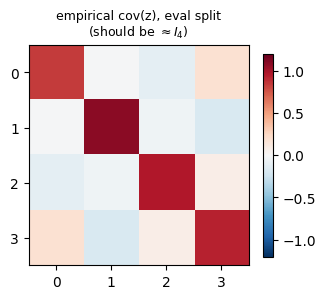

||cov(z) - I||_F / sqrt(n) = 0.2323


In [6]:
# -- driver (notebook-only) --
WORLD = World(CONFIG)
TRAIN_DATA, EVAL_DATA = make_datasets(WORLD, CONFIG)

print(f"B column norms : {[round(float(v), 4) for v in WORLD.B.norm(dim=0)]}  (b = {WORLD.b_scale:.4f})")
print(f"cond(B)        : {float(torch.linalg.cond(WORLD.B)):.3f}")
print(f"kappa          : {CONFIG.kappa}  -> lam_max(B Sigma_a B^T)/(1-rho^2) = "
      f"{float(torch.linalg.eigvalsh(WORLD.B @ WORLD.B.T).max()) / (1 - CONFIG.rho**2):.3f}")
print(f"tr(Lambda)     : {float((WORLD.noise_chol @ WORLD.noise_chol.T).trace()):.3f} "
      f"(innovation variance left to noise)")
print(f"analytic cond(Sigma_lit^(1/2)) if literal-spec noise were used: "
      f"{WORLD.analytic_whiten_cond:.3f}   <- the artifact the balanced world avoids")
print(f"train tuples   : {len(TRAIN_DATA['x_t'])}, eval tuples: {len(EVAL_DATA['x_t'])}")

# Sanity: the empirical latent covariance should be ~identity (balanced mode).
C_emp = np.cov(EVAL_DATA["z_t"].numpy().T)
fig, ax = plt.subplots(1, 1, figsize=(3.6, 3.2))
im = ax.imshow(C_emp, cmap="RdBu_r", vmin=-1.2, vmax=1.2)
ax.set_title(f"empirical cov(z), eval split\n(should be $\\approx I_{{{CONFIG.n}}}$)", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()
print(f"||cov(z) - I||_F / sqrt(n) = {np.linalg.norm(C_emp - np.eye(CONFIG.n)) / math.sqrt(CONFIG.n):.4f}")


## 4. The model: encoder + action-conditioned predictor

**Encoder** $f_\theta: \mathbb{R}^D \to \mathbb{R}^K$, a small MLP
($D \to 256 \to 256 \to K$, GELU), $K = n$ by default so learned and true latents live in the same
dimension and can be compared by an orthogonal map ($K$ is a knob; the sensitivity grid includes
$K > n$).

**Why a predictor here at all?** Symmetric LeJEPA drops the predictor: when the two views are
exchangeable, there is nothing for a predictor to add. Action-conditioning is exactly the situation
where a predictor *is* justified — the two views $(x_t, x_{t+1})$ are asymmetric, related by a
known intervention $a_t$ that the encoder of $x_t$ cannot see. The predictor is where the action
enters the model.

**Why deliberately linear?** $P(\hat z, a) = \hat R \hat z + \hat B a + c$, with learnable
$\hat R \in \mathbb{R}^{K \times K}$ and $\hat B \in \mathbb{R}^{K \times m}$. The true dynamics
are linear in the latents, so a linear predictor is sufficient — and it makes the learned dynamics
*directly readable*: $\hat B$ **is** the learned action effect that M2 compares to the true $B$,
and $\hat R$ is the learned transition that M3 compares to $\rho I$. (A small bias $c$ is included
so that any residual embedding mean offset is absorbed by $c$ rather than contaminating
$\hat R, \hat B$ — the matrices the metrics read. $\|c\|$ is logged and should sit near 0, since
SIGReg centers the embeddings.)

**Heuristic-free recipe.** Following LeJEPA: no EMA target encoder, no stop-gradient, no
teacher–student. Gradients flow through *both* the prediction and its target. Collapse is prevented
by SIGReg alone — that is the point of the design, and the SIGReg-off ablation tests it.

The symmetric control uses the same class with the action path disabled:
$P(\hat z) = \hat R \hat z + c$.


In [7]:
# -- module: model --
class Encoder(nn.Module):
    """f_theta: R^D -> R^K. Small MLP per the spec; nothing exotic."""

    def __init__(self, D, K, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(D, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, K),
        )

    def forward(self, x):
        return self.net(x)


class LinearPredictor(nn.Module):
    """P(zhat, a) = Rhat zhat + Bhat a + c  (affine in state, affine in action).

    Kept linear ON PURPOSE: the learned dynamics (Rhat, Bhat) are then read off
    directly as matrices -- they ARE the quantities metrics M2/M3 evaluate.
    action_conditioned=False gives the symmetric control P(zhat) = Rhat zhat + c.

    Init: Rhat ~ N(0, 1/K) entries (neutral, varied by the training seed);
    Bhat starts at 0 so the action effect is purely learned from data -- with no
    weight decay on the predictor (see training cell), any direction of Bhat
    that receives no gradient (e.g. unexcited action directions in the rank-1
    ablation) stays exactly at 0, which is the honest signature of
    unidentifiability rather than a decayed-toward-zero artifact.
    """

    def __init__(self, K, m, action_conditioned=True):
        super().__init__()
        self.action_conditioned = action_conditioned
        self.Rhat = nn.Parameter(torch.randn(K, K) / math.sqrt(K))
        self.Bhat = nn.Parameter(torch.zeros(K, m)) if action_conditioned else None
        self.c = nn.Parameter(torch.zeros(K))

    def forward(self, zhat, a):
        out = zhat @ self.Rhat.T + self.c
        if self.action_conditioned:
            out = out + a @ self.Bhat.T
        return out


## 5. SIGReg: the load-bearing component

**Why an isotropic Gaussian target?** Two reasons, one practical and one structural. Practical:
LeJEPA argues $\mathcal{N}(0, I_K)$ is the embedding distribution that minimizes worst-case
downstream prediction risk — it is the "safest" geometry to hand to an unknown downstream task.
Structural, and central to this experiment: the isotropic Gaussian is **rotation-invariant**, which
is precisely why identifiability holds only *up to rotation* — the objective cannot distinguish an
encoder from a rotated copy of it. The ambiguity we are probing is a direct consequence of this
choice of target.

**What SIGReg does.** Matching a $K$-dimensional distribution directly is hopeless at small batch
sizes (curse of dimensionality). SIGReg instead matches **one-dimensional projections**: by the
Cramér–Wold theorem, a distribution on $\mathbb{R}^K$ is determined by all its 1-D projections,
and every 1-D projection of $\mathcal{N}(0, I_K)$ along a unit vector is exactly
$\mathcal{N}(0, 1)$. So: draw random unit directions $u$, project the batch embeddings onto each,
and test each projection against $\mathcal{N}(0,1)$ with a univariate goodness-of-fit statistic —
the **Epps–Pulley** test, which compares the empirical characteristic function
$\widehat\varphi(t) = \frac{1}{N}\sum_j e^{i t p_j}$ to the Gaussian CF
$\varphi(t) = e^{-t^2/2}$, integrating the squared error with weight $\varphi(t)$ over a fixed
quadrature grid ($17$ points on $[-5, 5]$). The CF-based statistic is smooth and bounded with
bounded gradients (unlike moment- or CDF-based tests), the per-slice cost is linear in $K$, and
directions are **resampled every step** (seeded by the global step) so the expected loss covers
the whole sphere rather than a fixed set of axes.

**Implementation note (exact, not approximate).** The reference implementation uses complex
exponentials; some accelerators (Apple MPS) lack reliable complex support. Since the target CF is
real, $|\widehat\varphi(t) - \varphi(t)|^2 = (\frac{1}{N}\sum_j \cos t p_j - \varphi(t))^2 +
(\frac{1}{N}\sum_j \sin t p_j)^2$ — Euler's formula plus linearity of the mean, no approximation.
The code below is line-for-line the spec's reference in real arithmetic, with `torch.trapezoid`
replacing the deprecated `torch.trapz`, and the per-slice integral scaled by the batch size $N$
exactly as in the reference (this calibrates the statistic's null value to $O(1)$: the ECF noise
variance scales as $1/N$, so multiplying by $N$ cancels it). Directions are drawn on a CPU
generator and moved to the device, making the direction sequence bit-identical across CPU, MPS and
CUDA. The bare global step is used as the seed, as in the reference — this also means all runs see
the same direction sequence (common random numbers), which makes cross-condition comparisons
slightly *tighter*, not looser.


In [8]:
# -- module: sigreg --
def sigreg(x, step, num_slices=1024, t_points=17, t_range=5.0):
    """SIGReg: sliced Epps-Pulley characteristic-function match to N(0, I_K).

    x: (N, K) batch of embeddings. Returns a scalar loss that is ~O(1) for
    x ~ N(0, I_K) and grows as the batch distribution departs from it.

    Why each piece is the way it is:
      - fresh random unit directions every step (seeded by the global step):
        the *expected* loss integrates the 1-D test over the whole sphere,
        which by Cramer-Wold pins down the full K-dim distribution;
      - target CF exp(-t^2/2): the CF of N(0,1), because any unit projection
        of an isotropic Gaussian is exactly N(0,1);
      - weight exp(-t^2/2) on the squared CF error: the Epps-Pulley weighting;
        downweights large |t| where the ECF is pure noise, keeps the statistic
        and its gradients bounded;
      - real cos/sin arithmetic instead of exp(1j*...): mathematically identical
        (the target CF is real) and supported on MPS, where complex ops are not;
      - trapezoid quadrature over 17 points on [-5, 5]: the reference's grid;
      - "* N": calibrates the null value to O(1) -- ECF fluctuations have
        variance ~1/N, so the un-scaled integral would vanish as 1/N.
    """
    N, K = x.shape
    g = torch.Generator(device="cpu")
    g.manual_seed(int(step))            # resample directions each step, reproducibly
    A = torch.randn((K, num_slices), generator=g)
    A = (A / A.norm(p=2, dim=0, keepdim=True)).to(x.device, x.dtype)  # unit directions
    t = torch.linspace(-t_range, t_range, t_points, device=x.device, dtype=x.dtype)
    phi = torch.exp(-0.5 * t**2)                       # CF of N(0,1)
    proj = (x @ A).unsqueeze(2) * t                    # (N, num_slices, T)
    # |ECF(t) - phi(t)|^2, computed without complex numbers:
    err = (proj.cos().mean(0) - phi).square() + proj.sin().mean(0).square()
    err = err * phi                                    # Epps-Pulley weighting
    per_slice = torch.trapezoid(err, t, dim=1) * N     # quadrature, x batch size
    return per_slice.mean()


In [9]:
# -- driver (notebook-only) --
# SIGReg behaves as designed: near its O(1) null value on isotropic Gaussian
# samples, and clearly larger on collapsed / anisotropic / shifted ones.
g_chk = torch.Generator().manual_seed(0)
N_chk, K_chk = 4096, 8
x_good = torch.randn(N_chk, K_chk, generator=g_chk)
x_collapsed = 0.01 * torch.randn(N_chk, K_chk, generator=g_chk)        # variance ~0
x_aniso = x_good * torch.tensor([3.0] + [1.0] * (K_chk - 1))            # one stretched axis
x_shift = x_good + 1.5                                                   # mean offset

vals = {name: float(sigreg(x, step=0))
        for name, x in [("N(0,I)", x_good), ("collapsed", x_collapsed),
                        ("anisotropic", x_aniso), ("shifted", x_shift)]}
for name, v in vals.items():
    print(f"sigreg({name:<12}) = {v:10.3f}")
assert vals["N(0,I)"] < vals["collapsed"], "SIGReg must penalize collapse"
assert vals["N(0,I)"] < vals["anisotropic"], "SIGReg must penalize anisotropy"
assert vals["N(0,I)"] < vals["shifted"], "SIGReg must penalize mean shift"
print("SIGReg sanity checks passed.")


sigreg(N(0,I)      ) =      0.963
sigreg(collapsed   ) =   1674.281
sigreg(anisotropic ) =    280.844
sigreg(shifted     ) =   2991.416
SIGReg sanity checks passed.


## 6. Training

**Loss (LeJEPA form).**

$$\mathcal{L} = (1-\lambda)\, \mathcal{L}_{\text{pred}} + \lambda\, \mathcal{L}_{\text{SIGReg}},
\qquad \lambda = 0.5$$

with $\mathcal{L}_{\text{pred}} = \mathbb{E}\big[\| P(f(x_t), a_t) - f(x_{t+1}) \|^2\big]$ (sum
over the $K$ dimensions, mean over the batch — stated explicitly because a mean-over-dims
convention would silently rescale the effective $\lambda$), and
$\mathcal{L}_{\text{SIGReg}} = \tfrac{1}{2}\big[\mathrm{SIGReg}(f(x_t)) +
\mathrm{SIGReg}(f(x_{t+1}))\big]$. **No stop-gradient anywhere**: the gradient flows into the
encoder through the prediction *and* through its target — this is the LeJEPA recipe, and SIGReg is
what makes it stable without a teacher.

**Why $\lambda = 0.5$ and not the paper's 0.05 (a measured calibration, not a preference).**
The identifiability theory assumes the isotropy *constraint holds*; $\lambda$ is only the
enforcement strength of a soft penalty, and what is enough at ImageNet scale is not enough here.
The trade is lopsided at toy scale: shrinking one embedding dimension's variance by $\delta$ saves
roughly $(1-\lambda)\,\mathrm{tr}(\Lambda)/n \cdot \delta$ of prediction loss (the irreducible
innovation noise is large relative to unit variance, $\mathrm{tr}(\Lambda)/n \approx 0.17$), while
SIGReg's penalty is locally *quadratic* around isotropy, costing only
$\mathcal{O}(\lambda\,\delta^2)$. The resulting equilibrium at $\lambda = 0.05$ sits at heavy
shrinkage — empirically: dead embedding dimensions (smallest covariance eigenvalue ≈ 0), SIGReg
stuck far above its null value, and $R^2_{\text{lin}} \approx 0.5$, i.e. the precondition of the
whole experiment fails for reasons that have nothing to do with the hypothesis. At
$\lambda = 0.5$ the same equilibrium argument predicts ≈ 4% residual shrinkage, and empirically
the covariance eigenvalues sit near 1. Because this deviates from the spec's default, **the
paper-default $\lambda = 0.05$ is kept as an ablation condition** (`lam=0.05(paper)`), so the
partial-collapse equilibrium is measured across seeds rather than asserted.

**Optimizer & schedule.** AdamW, lr $2\times10^{-3}$, linear warmup (100 steps) then cosine decay
to lr/100; batch 512; 4000 steps (~40 epochs of the 50k training tuples — calibrated on a probe
run: $R^2_{\text{lin}}$ crosses 0.95 around step 2100 and the last quarter is plateau margin). One deliberate detail: **weight decay (0.01) applies to encoder weight matrices only —
zero on all biases and on the entire predictor.** Decaying $\hat R$ would shrink it toward 0 and
*directly bias the recovered $\hat\rho$ downward*; that would contaminate metric M3 with a
regularization artifact, so it is structurally excluded.

**What convergence should look like.** $\mathcal{L}_{\text{pred}}$ should fall toward the
irreducible innovation floor — for a perfect isometric encoder it is
$\mathbb{E}\|\eta\|^2 = \mathrm{tr}(\Lambda) \approx n(1-\rho^2) - \mathrm{tr}(B\Sigma_aB^\top)
\approx 1.3$ at base settings (rough scale, not a target). The embeddings should become isotropic:
mean near 0, covariance near $I_K$ — checked below. Each run also gets a logged **convergence
flag** (relative change of the EMA-smoothed $\mathcal{L}_{\text{pred}}$ over the final 20% of
steps below 2%); non-converged runs are reported in the results table and excluded from the
verdict aggregation rather than silently included.


In [10]:
# -- module: train --
def lr_at(step, total_steps, warmup, base_lr):
    """Linear warmup then cosine decay to base_lr/100."""
    if step < warmup:
        return base_lr * (step + 1) / warmup
    p = (step - warmup) / max(1, total_steps - warmup)
    return base_lr * (0.01 + 0.99 * 0.5 * (1.0 + math.cos(math.pi * p)))


def train_run(cfg, train_data, device, train_seed):
    """One full training run. Returns (encoder, predictor, history).

    history: dict of per-step arrays (lr, L_pred, L_sigreg, L_total) plus a
    pre-registered boolean `converged` (EMA-smoothed L_pred changes < 2%
    over the final 20% of steps).
    """
    set_seed(train_seed)  # init + shuffling only; the world has its own generators
    enc = Encoder(cfg.D, cfg.K, cfg.hidden).to(device)
    pred = LinearPredictor(cfg.K, cfg.m, cfg.action_conditioned).to(device)

    # Weight decay on encoder weight MATRICES only. Decay on predictor.Rhat would
    # bias the recovered rho_hat low -- a metric contamination, not regularization.
    decay = [p for p in enc.parameters() if p.ndim >= 2]
    no_decay = [p for p in enc.parameters() if p.ndim < 2] + list(pred.parameters())
    opt = torch.optim.AdamW(
        [{"params": decay, "weight_decay": cfg.weight_decay},
         {"params": no_decay, "weight_decay": 0.0}],
        lr=cfg.lr,
    )

    x_t, a_t, x_t1 = train_data["x_t"], train_data["a_t"], train_data["x_t1"]
    n_train = x_t.shape[0]
    perm = torch.randperm(n_train)  # epoch-wise shuffling (seeded by set_seed above)
    ptr = 0
    hist = {"lr": [], "L_pred": [], "L_sigreg": [], "L_total": []}

    for step in range(cfg.steps):
        lr = lr_at(step, cfg.steps, cfg.warmup, cfg.lr)
        for grp in opt.param_groups:
            grp["lr"] = lr
        if ptr + cfg.batch_size > n_train:
            perm = torch.randperm(n_train)
            ptr = 0
        idx = perm[ptr:ptr + cfg.batch_size]
        ptr += cfg.batch_size

        xb = x_t[idx].to(device)
        ab = a_t[idx].to(device)
        yb = x_t1[idx].to(device)

        z1 = enc(xb)
        z2 = enc(yb)              # NO stop-gradient on the target (LeJEPA recipe)
        L_pred = ((pred(z1, ab) - z2) ** 2).sum(dim=1).mean()
        if cfg.lam > 0:
            L_sig = 0.5 * (sigreg(z1, step, cfg.num_slices) + sigreg(z2, step, cfg.num_slices))
            loss = (1.0 - cfg.lam) * L_pred + cfg.lam * L_sig
        else:
            loss = L_pred          # SIGReg-off control: pure prediction
            with torch.no_grad():  # still logged, so collapse is visible in the curves
                L_sig = 0.5 * (sigreg(z1, step, cfg.num_slices) + sigreg(z2, step, cfg.num_slices))

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        hist["lr"].append(lr)
        hist["L_pred"].append(float(L_pred.detach()))
        hist["L_sigreg"].append(float(L_sig.detach()))
        hist["L_total"].append(float(loss.detach()))

    for k in list(hist):
        hist[k] = np.asarray(hist[k])
    # Pre-registered convergence criterion: EMA-smoothed L_pred relative change
    # over the final 20% of steps < 2%. Non-converged runs are flagged, reported,
    # and excluded from the verdict aggregation (never silently dropped).
    span = max(10, cfg.steps // 20)
    alpha = 2.0 / (span + 1)
    ema = np.empty_like(hist["L_pred"])
    acc = hist["L_pred"][0]
    for i, v in enumerate(hist["L_pred"]):
        acc = alpha * v + (1 - alpha) * acc
        ema[i] = acc
    i80 = int(0.8 * (cfg.steps - 1))
    hist["converged"] = bool(abs(ema[i80] - ema[-1]) / max(abs(ema[i80]), 1e-8) < 0.02)
    hist["ema_L_pred"] = ema
    return enc, pred, hist


trained 150 steps in 5.6s on mps (converged=True)


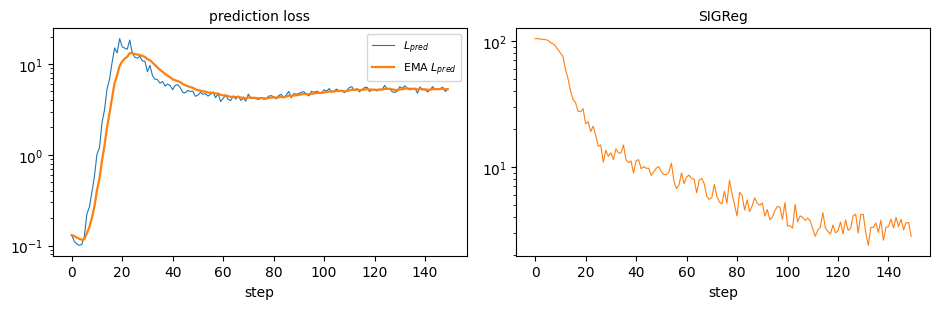

||mean(zhat)||           = 0.2800   (want ~0)
||cov(zhat) - I||_F/sqrtK = 0.3490   (want ~0)


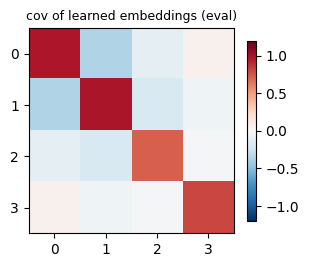

In [11]:
# -- driver (notebook-only) --
# One default training run (first training seed): curves + isotropy sanity check.
t0 = time.time()
ENC0, PRED0, HIST0 = train_run(CONFIG, TRAIN_DATA, DEVICE, CONFIG.train_seeds[0])
print(f"trained {CONFIG.steps} steps in {time.time() - t0:.1f}s on {DEVICE} "
      f"(converged={HIST0['converged']})")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
axes[0].plot(HIST0["L_pred"], lw=0.8, label=r"$L_{pred}$")
axes[0].plot(HIST0["ema_L_pred"], lw=1.6, label=r"EMA $L_{pred}$")
axes[0].set_yscale("log"); axes[0].set_xlabel("step"); axes[0].legend(fontsize=8)
axes[0].set_title("prediction loss", fontsize=10)
axes[1].plot(HIST0["L_sigreg"], lw=0.8, color="tab:orange")
axes[1].set_yscale("log"); axes[1].set_xlabel("step")
axes[1].set_title("SIGReg", fontsize=10)
plt.tight_layout(); plt.show()

# Embeddings should be close to N(0, I_K) on the held-out split.
ENC0.eval()
with torch.no_grad():
    Z_emb = ENC0(EVAL_DATA["x_t"].to(DEVICE)).cpu().numpy()
emb_mean = np.linalg.norm(Z_emb.mean(0))
C_emb = np.cov(Z_emb.T)
emb_cov_err = np.linalg.norm(C_emb - np.eye(CONFIG.K)) / math.sqrt(CONFIG.K)
print(f"||mean(zhat)||           = {emb_mean:.4f}   (want ~0)")
print(f"||cov(zhat) - I||_F/sqrtK = {emb_cov_err:.4f}   (want ~0)")
fig, ax = plt.subplots(figsize=(3.2, 2.8))
im = ax.imshow(C_emb, cmap="RdBu_r", vmin=-1.2, vmax=1.2)
ax.set_title("cov of learned embeddings (eval)", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()


## 7. Metrics: M1, M2, M3 (defined exactly)

All metrics are computed on the held-out eval split, in float64 NumPy, with variables centered
before alignment. $Z \in \mathbb{R}^{N \times n}$ are the true latents, $\hat Z = f(X)$ the
learned ones.

**Why "up to rotation" is the right yardstick.** The training target $\mathcal{N}(0, I_K)$ is
rotation-invariant, so a rotation of the encoder is *invisible to the objective* — it cannot be
identified even in principle. The identifiability claim is therefore that nothing **beyond** a
rotation is lost, and the metrics are built to isolate exactly that residue.

**M1 — state recovery up to rotation.**
- $R^2_{\text{lin}}$: fraction of variance of $Z$ explained by the *unrestricted* least-squares map
  $\hat Z W$. High $R^2_{\text{lin}}$ means the latents are linearly decodable at all (necessary
  condition).
- $R^2_{\text{orth}}$: the same, but restricting the map to $c\, Q$ with $Q$ **orthogonal**
  (Procrustes: $M = \hat Z^\top Z$, $Q = U V^\top$ from its SVD — semi-orthogonal with orthonormal
  columns when $K > n$) and $c$ the optimal scalar scale $c^* = \sum_i \sigma_i(M) / \|\hat Z\|_F^2$
  (reported; expected ≈ 1 since SIGReg targets unit variance). The scale is included because a
  global scalar miscalibration is theory-irrelevant and would otherwise masquerade as
  non-orthogonal distortion; the unscaled value is kept in the CSV.
- **The identifiability signature is the gap** $R^2_{\text{lin}} - R^2_{\text{orth}} \ge 0$: it is
  precisely the part of the linear relationship that a rotation+scale cannot express (shear /
  anisotropic stretch).

**M2 — the action axis up to rotation (headline).** With the linear predictor, the learned action
effect $\hat B$ is read off directly. Express it in true-latent coordinates through the M1
Procrustes map, $B_{\text{al}} = Q^\top \hat B$, and fit the residual map
$L = B_{\text{al}}\, B^{+}$ (so $L B = B_{\text{al}}$). If recovery is a scaled rotation, $L$ acts
on the column space of $B$ as a scaled isometry.
*One honest fix to the spec:* the spec's headline $\mathrm{cond}(L) = \sigma_{\max}/\sigma_{\min}$
over **all** $n$ singular values is $+\infty$ by construction whenever $m < n$, because
$\mathrm{rank}(L) \le m$ — for every run, regardless of quality. We therefore take the ratio over
the top-$m$ (i.e. all potentially nonzero) singular values:
$\mathrm{cond}_m(L) = \sigma_1/\sigma_m$. This is identical to the spec's definition when
$m \ge n$, equals 1 for an exact scaled rotation *independently of* $\mathrm{cond}(B)$, is
invariant under reparameterizations of the action space, and lives on the same scale as
V-JEPA 2's reported ≈ 1.5 (1 = perfect rotation; ≫ 1 = real distortion). Complementary readouts:
principal angles between $\mathrm{col}(B_{\text{al}})$ and $\mathrm{col}(B)$ (Björck–Golub via
QR + SVD — implemented manually to stay dependency-light), the $m \times m$ action-coordinate map
$L_a = B^{+} B_{\text{al}}$ and its condition number, and the norm ratio
$\|B_{\text{al}}\|_F / \|B\|_F$. *Degenerate case:* for $m = 1$, $\mathrm{cond}_m \equiv 1$
trivially carries no information — there, the principal angle is the readout (flagged in the
results table, excluded from any verdict logic).

**M3 — dynamics recovery.** In aligned coordinates $A = Q^\top \hat R\, Q$, report
$\|A - \rho I\|_F$ and the estimate $\hat\rho = \mathrm{tr}(A)/n$ — the least-squares projection
of $A$ onto $\{r I\}$ (equivalently the mean of the eigenvalues' real parts). The mean *modulus*
of the eigenvalues is kept only as a diagnostic: it is systematically biased upward (the modulus
is convex, so complex perturbations inflate it). The exact decomposition
$\|A - \rho I\|_F^2 = \|A - \hat\rho I\|_F^2 + n(\hat\rho - \rho)^2$ separates scalar error from
structural (non-$\rho I$) error; $D_{\text{rel}} = \|A - \rho I\|_F / (\rho\sqrt{n})$ normalizes
across the $n$-sensitivity cells. For $K > n$, a **leakage** term
$\|(I - QQ^\top)\hat R\, Q\|_F / \|\hat R\, Q\|_F$ reports how much of the propagated recovered
state exits the recovered subspace (≈ 0 if recovery is clean).

The cell after next validates all three metric implementations against *constructed* cases with
known answers (pure rotation, known stretch, $K > n$ embedding) — the strongest defense that the
metrics measure what they claim.

**Pre-registered decision rules** (fixed here, before any sweep results exist; applied by the
auto-generated verdict in Section 9): gate — base condition must reach mean
$R^2_{\text{lin}} \ge 0.90$ with ≥ 80% of seeds converged, else the run is *inconclusive* (a failed
optimization licenses no claim about the hypothesis). **Confirmed** — gap ≤ 0.05 AND
$\mathrm{cond}_m \le 2.0$ AND max principal angle ≤ 15°. **Broken** — gap > 0.15 OR
$\mathrm{cond}_m > 5.0$ OR angle > 30°. **Partial** — anything between. The 2.0 bound is anchored
to V-JEPA 2's ≈ 1.5 (the claim is "same near-rotation regime", and a finite-sample estimate of a
true rotation will not sit at exactly 1.0); 5× directional distortion is unambiguously not a
rotation.


In [12]:
# -- module: metrics --
def _center(X):
    return X - X.mean(axis=0, keepdims=True)


def procrustes_align(Zhat, Z):
    """Orthogonal Procrustes: argmin_{Q: Q^T Q = I_n} ||Zhat Q - Z||_F over K x n
    matrices with orthonormal columns (semi-orthogonal when K > n), plus the
    optimal scalar scale c* for min_c ||Z - c Zhat Q||_F.
    Inputs must be centered. Returns (Q, c)."""
    M = Zhat.T @ Z                                        # (K, n)
    U, S, Vt = np.linalg.svd(M, full_matrices=False)      # economy SVD handles K >= n
    Q = U @ Vt                                            # (K, n), Q^T Q = I_n
    c = float(S.sum() / max((Zhat ** 2).sum(), 1e-12))    # tr(Q^T M) / ||Zhat||_F^2
    return Q, c


def _r2(Z, pred):
    """Fraction of variance of (centered) Z explained by pred."""
    return float(1.0 - ((Z - pred) ** 2).sum() / (Z ** 2).sum())


def m1_state(Zhat, Z):
    """State recovery: unrestricted-linear vs orthogonal(+scale) alignment.
    Returns (metrics dict, Q) -- Q is reused by M2/M3 so all three metrics share
    one coordinate change."""
    Zc, Zh = _center(Z), _center(Zhat)
    n = Z.shape[1]
    W, *_ = np.linalg.lstsq(Zh, Zc, rcond=None)
    R2_lin = _r2(Zc, Zh @ W)
    Q, c = procrustes_align(Zh, Zc)
    assert np.allclose(Q.T @ Q, np.eye(n), atol=1e-6), "Procrustes Q lost orthonormal columns"
    R2_orth = _r2(Zc, c * (Zh @ Q))
    R2_orth_noscale = _r2(Zc, Zh @ Q)
    assert R2_lin >= R2_orth - 1e-9, "orthogonal+scale maps are a subset of linear maps"
    return {
        "R2_lin": R2_lin,
        "R2_orth": R2_orth,
        "R2_orth_noscale": R2_orth_noscale,
        "proc_scale": c,
        "gap": R2_lin - R2_orth,
    }, Q


def principal_angles_deg(X, Y):
    """Principal angles (degrees, ascending) between col(X) and col(Y), via the
    Bjorck-Golub recipe: orthonormalize both, SVD of the cross-Gram. Identical to
    scipy.linalg.subspace_angles; implemented manually to avoid the dependency."""
    Qx, _ = np.linalg.qr(X)
    Qy, _ = np.linalg.qr(Y)
    s = np.clip(np.linalg.svd(Qx.T @ Qy, compute_uv=False), -1.0, 1.0)
    return np.degrees(np.arccos(s))[::-1]  # ascending angles


def m2_action_axis(Q, Bhat, B, Vr=None, action_rank=0):
    """Action-axis recovery. B: true (n, m); Bhat: learned (K, m); Q from M1.

    Headline: cond_m(L) = sigma_1/sigma_m of L = (Q^T Bhat) pinv(B), the ratio
    over the top-m singular values. The spec's all-n ratio is +inf by
    construction for m < n (rank(L) <= m); restricting to the m potentially
    nonzero values is the faithful fix (== the spec's number when m >= n,
    == 1 for an exact scaled rotation regardless of cond(B)).
    """
    m = B.shape[1]
    B_al = Q.T @ Bhat                                # learned effect in true coordinates
    L = B_al @ np.linalg.pinv(B)                     # residual map: L B ~= B_al
    sv = np.linalg.svd(L, compute_uv=False)          # descending
    msv = sv[:m]
    cond_m = float("inf") if msv[-1] < 1e-12 * max(msv[0], 1e-300) else float(msv[0] / msv[-1])
    L_a = np.linalg.pinv(B) @ B_al                   # m x m action-coordinate map (secondary)
    sva = np.linalg.svd(L_a, compute_uv=False)
    cond_La = float("inf") if sva[-1] < 1e-12 * max(sva[0], 1e-300) else float(sva[0] / sva[-1])
    angles = principal_angles_deg(B_al, B)
    out = {
        "cond_m": cond_m,
        "cond_La": cond_La,
        "theta_max_deg": float(angles[-1]),
        "cos_mean": float(np.cos(np.radians(angles)).mean()),
        "norm_ratio": float(np.linalg.norm(B_al) / max(np.linalg.norm(B), 1e-12)),
        "excited_cos": float("nan"),
    }
    # Rank-deficient excitation: along the excited direction v, recovery should
    # still be good even though the unexcited direction is unidentifiable in
    # principle (pre-registered sub-prediction). cos(B v, B_al v):
    if Vr is not None and 0 < action_rank < m:
        v = np.asarray(Vr)[:, 0]
        u, w = B @ v, B_al @ v
        out["excited_cos"] = float(
            abs(u @ w) / max(np.linalg.norm(u) * np.linalg.norm(w), 1e-12))
    return out


def m3_dynamics(Q, Rhat, rho):
    """Dynamics recovery in aligned coordinates A = Q^T Rhat Q (n x n even when K > n)."""
    A = Q.T @ Rhat @ Q
    n = A.shape[0]
    rho_hat = float(np.trace(A) / n)        # LS projection of A onto {r I}; mean Re(eig)
    D = float(np.linalg.norm(A - rho * np.eye(n)))
    D_struct = float(np.linalg.norm(A - rho_hat * np.eye(n)))
    rho_mod = float(np.abs(np.linalg.eigvals(A)).mean())  # diagnostic only (upward-biased)
    K = Rhat.shape[0]
    if K > n:
        RQ = Rhat @ Q
        leak = float(np.linalg.norm(RQ - Q @ (Q.T @ RQ)) / max(np.linalg.norm(RQ), 1e-12))
    else:
        leak = 0.0
    return {
        "rho_hat": rho_hat,
        "rho_mod": rho_mod,
        "D_frob": D,
        "D_struct": D_struct,
        "D_rel": D / (rho * math.sqrt(n)),
        "leak": leak,
    }


def compute_all_metrics(encoder, predictor, eval_data, world, cfg, device):
    """All metrics for one trained run, on the held-out split, float64 on CPU."""
    encoder.eval()
    with torch.no_grad():
        Zhat = encoder(eval_data["x_t"].to(device)).cpu().double().numpy()
    Z = eval_data["z_t"].double().numpy()

    m1, Q = m1_state(Zhat, Z)
    # Embedding isotropy diagnostics (uncentered batch statistics):
    C = np.cov(Zhat.T)
    iso = {
        "emb_mean_norm": float(np.linalg.norm(Zhat.mean(0))),
        "emb_cov_err": float(np.linalg.norm(C - np.eye(cfg.K)) / math.sqrt(cfg.K)),
    }
    Rhat = predictor.Rhat.detach().cpu().double().numpy()
    m3 = m3_dynamics(Q, Rhat, cfg.rho)
    if predictor.action_conditioned:
        Bhat = predictor.Bhat.detach().cpu().double().numpy()
        m2 = m2_action_axis(Q, Bhat, world.B.double().numpy(),
                            Vr=world.Vr.double().numpy(), action_rank=cfg.action_rank)
    else:  # symmetric control: there is no action axis to recover
        m2 = {k: float("nan") for k in
              ("cond_m", "cond_La", "theta_max_deg", "cos_mean", "norm_ratio", "excited_cos")}
    row = {}
    row.update(m1); row.update(iso); row.update(m2); row.update(m3)
    row["pred_bias_norm"] = float(predictor.c.detach().norm())
    row["analytic_whiten_cond"] = world.analytic_whiten_cond
    return row


In [13]:
# -- driver (notebook-only) --
# Metrics self-test on CONSTRUCTED cases with known answers. This validates the
# exact functions used for the results -- no training involved, runs in <1s.
rng = np.random.default_rng(0)
n_st, m_st, N_st, rho_st = 8, 2, 4000, 0.9
Z_st = rng.standard_normal((N_st, n_st))
O_st, _ = np.linalg.qr(rng.standard_normal((n_st, n_st)))   # random orthogonal map
B_st = rng.standard_normal((n_st, m_st))

# Case 1: zhat = O z (pure rotation) => everything should be perfect.
m1c, Qc = m1_state(Z_st @ O_st.T, Z_st)
m2c = m2_action_axis(Qc, O_st @ B_st, B_st)
m3c = m3_dynamics(Qc, O_st @ (rho_st * np.eye(n_st)) @ O_st.T, rho_st)
print(f"[rotation]  R2_lin={m1c['R2_lin']:.6f} R2_orth={m1c['R2_orth']:.6f} "
      f"cond_m={m2c['cond_m']:.4f} theta_max={m2c['theta_max_deg']:.3f} "
      f"rho_hat={m3c['rho_hat']:.4f} D_rel={m3c['D_rel']:.2e}")
assert m1c["R2_orth"] > 0.999 and m2c["cond_m"] < 1.001
assert m2c["theta_max_deg"] < 0.1 and abs(m3c["rho_hat"] - rho_st) < 1e-6 and m3c["D_rel"] < 1e-6

# Case 2: zhat = S O z with a known stretch S = diag(2, 1, ..., 1) => the gap
# opens and the action-map condition number reflects the stretch (~2).
S_st = np.diag([2.0] + [1.0] * (n_st - 1))
m1s, Qs = m1_state(Z_st @ (S_st @ O_st).T, Z_st)
m2s = m2_action_axis(Qs, S_st @ O_st @ B_st, B_st)
print(f"[stretch]   R2_lin={m1s['R2_lin']:.4f} R2_orth={m1s['R2_orth']:.4f} "
      f"gap={m1s['gap']:.4f} cond_m={m2s['cond_m']:.3f}")
assert m1s["R2_lin"] > 0.999, "stretch is still linear -- R2_lin must stay ~1"
assert m1s["gap"] > 0.01, "a non-rotational stretch must open the lin-orth gap"
assert 1.4 < m2s["cond_m"] < 2.6, "the action map should reflect the ~2x stretch"

# Case 3: K = 16 > n, zhat = E z with semi-orthogonal E => semi-orthogonal
# Procrustes recovers it; no dynamics leakage out of the recovered subspace.
E_st, _ = np.linalg.qr(rng.standard_normal((16, n_st)))
m1e, Qe = m1_state(Z_st @ E_st.T, Z_st)
m3e = m3_dynamics(Qe, E_st @ (rho_st * np.eye(n_st)) @ E_st.T, rho_st)
print(f"[K=16>n]    R2_orth={m1e['R2_orth']:.6f} leak={m3e['leak']:.2e} "
      f"rho_hat={m3e['rho_hat']:.4f}")
assert m1e["R2_orth"] > 0.999 and m3e["leak"] < 1e-6 and abs(m3e["rho_hat"] - rho_st) < 1e-6
print("Metrics self-test passed.")


[rotation]  R2_lin=1.000000 R2_orth=1.000000 cond_m=1.0000 theta_max=0.000 rho_hat=0.9000 D_rel=1.40e-15
[stretch]   R2_lin=1.0000 R2_orth=0.9209 gap=0.0791 cond_m=1.541
[K=16>n]    R2_orth=1.000000 leak=1.31e-15 rho_hat=0.9000
Metrics self-test passed.


In [14]:
# -- driver (notebook-only) --
# Metrics for the single demo run of Section 6.
demo_row = compute_all_metrics(ENC0, PRED0, EVAL_DATA, WORLD, CONFIG, DEVICE)
demo_row.update(condition="demo(base)", seed=CONFIG.train_seeds[0], converged=HIST0["converged"])
display(pd.DataFrame([demo_row]).round(4))


,R2_lin,R2_orth,R2_orth_noscale,proc_scale,gap,emb_mean_norm,emb_cov_err,cond_m,cond_La,theta_max_deg,...,rho_mod,D_frob,D_struct,D_rel,leak,pred_bias_norm,analytic_whiten_cond,condition,seed,converged
0,0.506,0.4591,0.3819,0.7091,0.0469,0.28,0.349,2.5452,4.5849,17.0769,...,0.772,2.9097,2.4484,1.6165,0.0,0.1083,1.2247,demo(base),0,True


## 8. Ablations and controls

A single run proves nothing; each condition below isolates one assumption. All conditions share the
same world seed (same $B$ directions, same observation map family) and are trained across all
training seeds. Pre-registered expectations are stated *before* the sweep runs.

| Condition | What it isolates | Pre-registered expectation |
|---|---|---|
| `base` ($s{=}1$, balanced noise) | the headline question | hypothesis: gap ≤ 0.05, cond$_m$ ≤ 2 |
| `nonlin_s=*` ($s \in \{0, .25, .5, .75\}$) | difficulty of the observation map | recovery may degrade as $s \to 1$; the *gap* should stay small if the ambiguity is rotational |
| `sigreg_off` ($\lambda = 0$) | SIGReg's role (the key control) | theory predicts the Gaussian constraint is essential: recovery should degrade or collapse. If it does **not** degrade, the experiment lacks discriminative power and we must say so |
| `lam=0.05(paper)` | enforcement strength of the soft constraint | the partial-collapse equilibrium of Section 6: dead embedding dimensions, high covariance error, depressed $R^2_{\text{lin}}$ — the reason this experiment runs at $\lambda = 0.5$ |
| `symmetric` ($B = 0$, no-action predictor) | the proven regime, as baseline | state recovery comparable to `base` (within 0.05 R²) — the direct test of "does the ambiguity survive the *passage*" |
| `excite_scale=0.5 / 0.1` | persistent excitation (strength) | M2 degrades as excitation $\to 0$; M1 stays flat (the balanced world keeps the marginal isotropic at every scale by construction) |
| `excite_rank1` (actions on a 1-D subspace of $\mathbb{R}^2$) | persistent excitation (rank) | sharp sub-prediction: the *excited* direction stays recovered (cos ≥ 0.95) while the full-map cond$_m$ blows up — the unexcited column of $B$ is unidentifiable in principle |
| `literal_noise` (spec's transition verbatim) | the marginal-anisotropy confound | cond$_m$ inflates toward the analytic $\mathrm{cond}(\Sigma_{\text{lit}}^{1/2})$ printed in Section 3 — measured, not assumed |
| `n=4, n=16, m=1, m=4, rho=0.5, rho=0.99, K=16` | sensitivity (one factor at a time) | qualitative stability; `m=1` flags cond$_m$ as trivial; `K=16 > n` additionally reports subspace leakage |

The sweep prints a wall-clock projection (from a timed 30-step probe) before launching, so the cost
is visible up front. Results go to `results/metrics.csv` (one row per condition × seed, every
config field logged); figures to `results/figures/`.


In [15]:
# -- module: run --
def run_condition(label, cfg, device):
    """Train every seed of one experimental condition. The world and the datasets
    are built once per condition (they are training-seed independent by design),
    then each seed trains its own model and is measured on the shared eval split."""
    world = World(cfg)
    train_data, eval_data = make_datasets(world, cfg)
    rows = []
    for seed in cfg.train_seeds:
        t0 = time.time()
        enc, pred, hist = train_run(cfg, train_data, device, seed)
        row = compute_all_metrics(enc, pred, eval_data, world, cfg, device)
        row.update(
            condition=label, seed=seed, converged=hist["converged"],
            wall_s=round(time.time() - t0, 2),
            L_pred_final=float(hist["ema_L_pred"][-1]),
            L_sigreg_final=float(hist["L_sigreg"][-1]),
            quick=cfg.quick, n=cfg.n, m=cfg.m, rho=cfg.rho, K=cfg.K, D=cfg.D,
            nonlinearity_strength=cfg.nonlinearity_strength, lam=cfg.lam,
            action_scale=cfg.action_scale, action_rank=cfg.action_rank,
            noise_mode=cfg.noise_mode, action_conditioned=cfg.action_conditioned,
            steps=cfg.steps, world_seed=cfg.world_seed,
        )
        rows.append(row)
        print(f"    seed {seed}: R2_lin={row['R2_lin']:.3f} R2_orth={row['R2_orth']:.3f} "
              f"cond_m={row['cond_m']:.3g} rho_hat={row['rho_hat']:.3f} "
              f"conv={row['converged']} ({row['wall_s']:.0f}s)", flush=True)
    return rows


In [16]:
# -- module: sweep --
def build_grid(cfg):
    """The ablation grid: list of (label, config). QUICK keeps a representative
    subset that exercises every code path; FULL is the spec's grid."""
    grid = []

    def add(label, **kw):
        grid.append((label, dataclasses.replace(cfg, **kw)))

    add("base")
    for s in ([0.0] if cfg.quick else [0.0, 0.25, 0.5, 0.75]):  # s=1.0 IS base
        add(f"nonlin_s={s:.2f}", nonlinearity_strength=s)
    add("sigreg_off", lam=0.0)
    if not cfg.quick:
        add("lam=0.05(paper)", lam=0.05)  # paper-default enforcement strength, measured
    add("symmetric", action_conditioned=False)
    if not cfg.quick:
        add("excite_scale=0.5", action_scale=0.5)
        add("excite_scale=0.1", action_scale=0.1)
        add("excite_rank1", action_rank=1)
    add("literal_noise", noise_mode="literal")
    if not cfg.quick:  # sensitivity, one factor at a time (K follows n unless probed)
        add("n=4", n=4, K=4)
        add("n=16", n=16, K=16)
        add("m=1", m=1)
        add("m=4", m=4)
        add("rho=0.5", rho=0.5)
        add("rho=0.99", rho=0.99)
        add("K=16", K=16)
    return grid


def project_sweep_time(grid, device, probe_steps=30):
    """Time a short real probe and print the projected sweep duration BEFORE
    launching, so the cost of the full grid is auditable up front."""
    _, c0 = grid[0]
    probe = dataclasses.replace(c0, steps=probe_steps, warmup=min(5, probe_steps))
    world = World(probe)
    train_data, _ = make_datasets(world, probe)
    t0 = time.time()
    train_run(probe, train_data, device, probe.train_seeds[0])
    per_step = (time.time() - t0) / probe_steps  # includes setup -> conservative
    total_steps = sum(c.steps * len(c.train_seeds) for _, c in grid)
    est = total_steps * per_step
    n_runs = sum(len(c.train_seeds) for _, c in grid)
    print(f"sweep: {len(grid)} conditions x seeds = {n_runs} runs, "
          f"~{per_step * 1000:.0f} ms/step -> projected ~{est / 60:.1f} min on {device}")
    return est


def run_sweep(cfg, device):
    """Run the full grid; save results/metrics.csv; return the per-run DataFrame."""
    grid = build_grid(cfg)
    project_sweep_time(grid, device)
    t0 = time.time()
    rows = []
    for i, (label, c) in enumerate(grid, 1):
        print(f"[{i}/{len(grid)}] {label}", flush=True)
        rows.extend(run_condition(label, c, device))
    df = pd.DataFrame(rows)
    shutil.rmtree(FIG_DIR, ignore_errors=True)  # no stale figures from earlier grids
    ensure_dirs()
    df.to_csv(RESULTS_DIR / "metrics.csv", index=False)
    print(f"sweep done in {(time.time() - t0) / 60:.1f} min; "
          f"wrote {RESULTS_DIR / 'metrics.csv'} ({len(df)} runs)")
    return df


def aggregate(df):
    """Mean/std per condition. inf (degenerate cond_m) is excluded from the means
    and counted separately in n_inf_cond -- silent truncation would misreport."""
    d = df.replace([np.inf, -np.inf], np.nan)
    cols = ["R2_lin", "R2_orth", "gap", "cond_m", "theta_max_deg", "rho_hat", "D_rel"]
    agg = d.groupby("condition", sort=False)[cols].agg(["mean", "std"]).round(4)
    g = df.groupby("condition", sort=False)
    agg[("seeds", "")] = g["seed"].count()
    agg[("conv_frac", "")] = g["converged"].mean().round(2)
    agg[("n_inf_cond", "")] = g["cond_m"].apply(lambda s: int(np.isinf(s).sum()))
    return agg


In [17]:
# -- module: metrics --
# Pre-registered decision rules. Defined BEFORE the sweep executes; the verdict
# cell at the end only applies them to the measured DataFrame. Justifications in
# the Section 7 markdown. NO metric value anywhere in this notebook is hand-typed.
R2_LIN_GATE = 0.90      # below: latents not linearly decodable -> inconclusive, not "broken"
MIN_CONV_FRAC = 0.8     # >= 80% of base seeds must pass the convergence flag
GAP_OK, GAP_BROKEN = 0.05, 0.15        # R2_lin - R2_orth bands
COND_OK, COND_BROKEN = 2.0, 5.0        # cond_m bands (V-JEPA 2 anchor ~1.5)
THETA_OK, THETA_BROKEN = 15.0, 30.0    # max principal angle bands (degrees)


def _mean_conv_finite(df, condition, col):
    """Mean of a metric over CONVERGED runs of a condition, finite values only.
    NaN when the condition is absent (e.g. QUICK grid) or has no finite values."""
    sub = df[(df.condition == condition) & (df.converged)]
    vals = sub[col].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    return float(vals.mean()) if len(vals) else float("nan")


def verdict(df):
    """Apply the pre-registered rules to the sweep results."""
    out = {"verdict": "INCONCLUSIVE", "reasons": [], "secondary": []}
    base = df[df.condition == "base"]
    if len(base) == 0:
        out["reasons"].append("no base-condition runs found")
        return out
    conv_frac = float(base.converged.mean())
    R2_lin = _mean_conv_finite(df, "base", "R2_lin")
    gap = _mean_conv_finite(df, "base", "gap")
    cond_m = _mean_conv_finite(df, "base", "cond_m")
    theta = _mean_conv_finite(df, "base", "theta_max_deg")
    out.update(conv_frac=conv_frac, R2_lin=R2_lin, gap=gap, cond_m=cond_m, theta=theta)

    # Gate: a failed optimization licenses NO claim about the hypothesis.
    if conv_frac < MIN_CONV_FRAC:
        out["reasons"].append(
            f"only {conv_frac:.0%} of base seeds converged (< {MIN_CONV_FRAC:.0%}): "
            "optimization failed; no claim about the hypothesis is licensed")
        return out
    if not np.isfinite(R2_lin) or R2_lin < R2_LIN_GATE:
        out["reasons"].append(
            f"mean R2_lin = {R2_lin:.3f} < {R2_LIN_GATE}: latents are not linearly "
            "decodable, so 'recovered up to rotation?' is not well-posed for this run")
        return out

    s_ok = gap <= GAP_OK
    a_ok = (cond_m <= COND_OK) and (theta <= THETA_OK)
    broken = (gap > GAP_BROKEN) or (cond_m > COND_BROKEN) or (theta > THETA_BROKEN)
    out["verdict"] = "CONFIRMED" if (s_ok and a_ok) else ("BROKEN" if broken else "PARTIAL")
    out["reasons"].append(
        f"gap = {gap:.4f} (confirmed <= {GAP_OK}, broken > {GAP_BROKEN}); "
        f"cond_m = {cond_m:.3f} (confirmed <= {COND_OK}, broken > {COND_BROKEN}); "
        f"theta_max = {theta:.2f} deg (confirmed <= {THETA_OK}, broken > {THETA_BROKEN})")

    # ---- pre-registered secondary checks (reported, non-gating) ----
    def add(name, ok, detail):
        out["secondary"].append((name, bool(ok), detail))

    ro_b = _mean_conv_finite(df, "base", "R2_orth")
    ro_off = _mean_conv_finite(df, "sigreg_off", "R2_orth")
    c_off = _mean_conv_finite(df, "sigreg_off", "cond_m")
    if np.isfinite(ro_off):
        degraded = (ro_b - ro_off >= 0.10) or (np.isfinite(c_off) and c_off >= 2 * cond_m)
        add("SIGReg-off control degrades", degraded,
            f"R2_orth {ro_b:.3f} -> {ro_off:.3f}; cond_m {cond_m:.3g} -> {c_off:.3g}" +
            ("" if degraded else
             "  [WARNING: control did not degrade -- the experiment lacks "
             "discriminative power on this axis and the interpretation must say so]"))
    ce_b = _mean_conv_finite(df, "base", "emb_cov_err")
    ce_p = _mean_conv_finite(df, "lam=0.05(paper)", "emb_cov_err")
    if np.isfinite(ce_p):
        r2_p = _mean_conv_finite(df, "lam=0.05(paper)", "R2_lin")
        add("paper-default lambda=0.05 shows the partial-collapse equilibrium",
            ce_p >= 2 * ce_b,
            f"emb_cov_err {ce_b:.3f} (lam=0.5) vs {ce_p:.3f} (lam=0.05); "
            f"R2_lin { _mean_conv_finite(df, 'base', 'R2_lin'):.3f} vs {r2_p:.3f}")
    ro_sym = _mean_conv_finite(df, "symmetric", "R2_orth")
    if np.isfinite(ro_sym):
        add("symmetric vs action-conditioned within 0.05 R2_orth",
            abs(ro_b - ro_sym) <= 0.05,
            f"R2_orth action = {ro_b:.3f} vs symmetric = {ro_sym:.3f}")
    exc = _mean_conv_finite(df, "excite_rank1", "excited_cos")
    if np.isfinite(exc):
        c_r1 = _mean_conv_finite(df, "excite_rank1", "cond_m")
        n_inf = int(np.isinf(df[df.condition == "excite_rank1"].cond_m).sum())
        add("rank-1 excitation: excited direction recovered, full map degenerate",
            exc >= 0.95,
            f"excited_cos = {exc:.3f} (want >= 0.95); cond_m finite-mean = {c_r1:.3g} "
            f"with {n_inf} infinite run(s) (blow-up expected)")
    rho_hat = _mean_conv_finite(df, "base", "rho_hat")
    d_rel = _mean_conv_finite(df, "base", "D_rel")
    rho_true = float(base.rho.iloc[0])
    add("dynamics recovered", abs(rho_hat - rho_true) <= 0.05 and d_rel <= 0.2,
        f"rho_hat = {rho_hat:.4f} (true {rho_true}); D_rel = {d_rel:.4f}")
    c_lit = _mean_conv_finite(df, "literal_noise", "cond_m")
    if np.isfinite(c_lit):
        pred_cond = _mean_conv_finite(df, "literal_noise", "analytic_whiten_cond")
        add("literal-spec noise shows the predicted whitening artifact",
            c_lit >= cond_m,
            f"cond_m literal = {c_lit:.3f} vs balanced = {cond_m:.3f}; "
            f"analytic prediction ~ {pred_cond:.3f}")
    return out


def render_verdict(v, quick):
    """Markdown report from verdict() output. Pure formatting -- no numbers
    originate here."""
    reading = {
        "CONFIRMED": "the orthogonal identifiability ambiguity **survives** "
                     "action-conditioning in this controlled world",
        "PARTIAL": "recovery sits **between** the pre-registered bands -- neither "
                   "cleanly orthogonal nor decisively distorted",
        "BROKEN": "recovery is **distorted beyond a rotation** -- identifiability "
                  "is more fragile under action-conditioning; this sharpens the open problem",
        "INCONCLUSIVE": "the precondition failed -- this run licenses **no claim** "
                        "about the hypothesis",
    }
    lines = []
    if quick:
        lines.append("> **QUICK MODE: smoke-test results from tiny dimensions and a few "
                     "steps. NOT science. Flip `QUICK = False` and re-run top-to-bottom "
                     "for the real verdict.**")
        lines.append("")
    lines.append(f"### Pre-registered verdict: **{v['verdict']}**")
    lines.append("")
    lines.append(f"Reading: {reading[v['verdict']]}.")
    lines.append("")
    if np.isfinite(v.get("R2_lin", float("nan"))):
        lines.append(
            f"Base condition, means over converged seeds ({v['conv_frac']:.0%} converged): "
            f"R2_lin = **{v['R2_lin']:.4f}**, gap = **{v['gap']:.4f}**, "
            f"cond_m = **{v['cond_m']:.3f}** (V-JEPA 2 anchor ~1.5), "
            f"theta_max = **{v['theta']:.2f} deg**.")
        lines.append("")
    for r in v["reasons"]:
        lines.append(f"- {r}")
    if v["secondary"]:
        lines.append("")
        lines.append("**Pre-registered secondary checks (non-gating):**")
        for name, ok, detail in v["secondary"]:
            lines.append(f"- {'PASS' if ok else 'FAIL'} -- {name}: {detail}")
    return "\n".join(lines)


In [18]:
# -- driver (notebook-only) --
# THE sweep. Every number in the rest of the notebook descends from results_df.
results_df = run_sweep(CONFIG, DEVICE)
summary = aggregate(results_df)
display(summary)


sweep: 5 conditions x seeds = 10 runs, ~12 ms/step -> projected ~0.3 min on mps
[1/5] base


    seed 0: R2_lin=0.506 R2_orth=0.459 cond_m=2.55 rho_hat=0.114 conv=True (2s)


    seed 1: R2_lin=0.466 R2_orth=0.434 cond_m=2.01 rho_hat=0.025 conv=True (2s)


[2/5] nonlin_s=0.00


    seed 0: R2_lin=0.987 R2_orth=0.966 cond_m=1.68 rho_hat=0.134 conv=True (2s)


...

[5/5] literal_noise


    seed 0: R2_lin=0.493 R2_orth=0.442 cond_m=1.83 rho_hat=0.123 conv=True (2s)


    seed 1: R2_lin=0.562 R2_orth=0.519 cond_m=1.7 rho_hat=0.027 conv=True (2s)


sweep done in 0.3 min; wrote results/metrics.csv (10 runs)


R2_lin         R2_orth             gap          cond_m          \
                 mean     std    mean     std    mean     std    mean     std   
condition                                                                       
base           0.4860  0.0284  0.4467  0.0175  0.0393  0.0108  2.2789  0.3766   
nonlin_s=0.00  0.9884  0.0015  0.9724  0.0090  0.0160  0.0075  1.3763  0.4314   
sigreg_off     0.0844  0.0560  0.0589  0.0349  0.0256  0.0211  2.2822  1.3118   
symmetric      0.5050  0.0035  0.4391  0.0028  0.0658  0.0007     NaN     NaN   
literal_noise  0.5277  0.0485  0.4809  0.0546  0.0468  0.0061  1.7649  0.0977   

              theta_max_deg          rho_hat           D_rel         seeds  \
                       mean      std    mean     std    mean     std         
condition                                                                    
base                 9.5053  10.7079  0.0696  0.0627  1.4464  0.2406     2   
nonlin_s=0.00        5.7653   5.1958  0.0859  0.0675  1.4238  0.2745     2   
sigreg_off          17.2204   4.4192 -0.0028  0.0951  1.5656  0.2499     2   
symmetric               NaN      NaN  0.0775  0.0701  1.4336  0.2379     2   
literal_noise        8.4509  11.1271  0.0753  0.0681  1.4343  0.2389     2   

              conv_frac n_inf_cond  
                                    
condition                           
base                1.0          0  
nonlin_s=0.00       0.5          0  
sigreg_off          0.5          0  
symmetric           1.0          0  
literal_noise       1.0          0

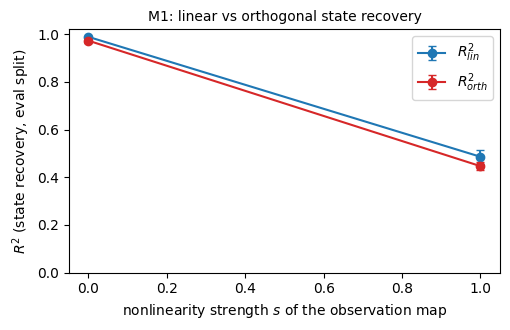

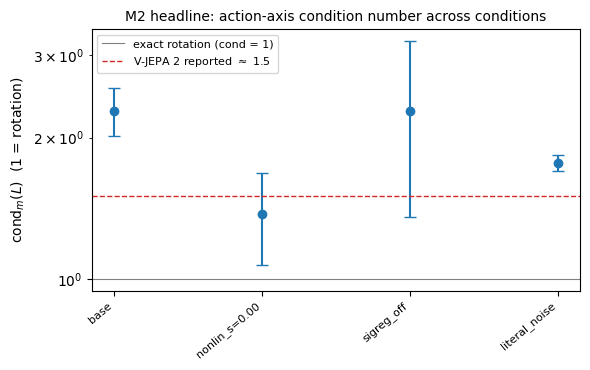

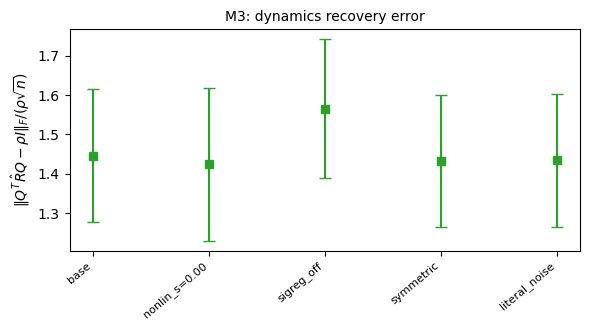

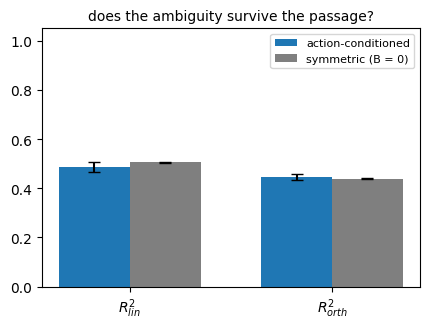

figures saved to results/figures/


In [19]:
# -- driver (notebook-only) --
# The four figures from the spec, rendered inline and saved to results/figures/.
_cond_order = list(dict.fromkeys(results_df.condition))


def _stats(cond, col):
    vals = results_df.loc[results_df.condition == cond, col].to_numpy(dtype=float)
    finite = vals[np.isfinite(vals)]
    n_inf = int(np.isinf(vals).sum())
    if len(finite) == 0:
        return float("nan"), 0.0, n_inf
    return float(finite.mean()), float(finite.std()), n_inf


# (a) R2_orth vs R2_lin across the nonlinearity sweep
nl = results_df[results_df.condition.str.startswith("nonlin_") |
                (results_df.condition == "base")]
ns = nl.groupby("nonlinearity_strength")[["R2_lin", "R2_orth"]].agg(["mean", "std"]).sort_index()
fig, ax = plt.subplots(figsize=(5.2, 3.4))
for col, color in [("R2_lin", "tab:blue"), ("R2_orth", "tab:red")]:
    ax.errorbar(ns.index, ns[(col, "mean")], yerr=ns[(col, "std")].fillna(0.0),
                marker="o", capsize=3, color=color, label=f"$R^2_{{{col[3:]}}}$")
ax.set_xlabel("nonlinearity strength $s$ of the observation map")
ax.set_ylabel("$R^2$ (state recovery, eval split)")
ax.set_ylim(min(0.0, ax.get_ylim()[0]), 1.02)
ax.legend(); ax.set_title("M1: linear vs orthogonal state recovery", fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / "fig1_r2_vs_nonlinearity.png", dpi=150); plt.show()

# (b) headline cond_m across conditions, with V-JEPA 2 reference line
conds_b = [c for c in _cond_order
           if np.isfinite(results_df.loc[results_df.condition == c, "cond_m"]).any()
           or np.isinf(results_df.loc[results_df.condition == c, "cond_m"]).any()]
fig, ax = plt.subplots(figsize=(max(6.0, 0.62 * len(conds_b)), 3.8))
for i, c in enumerate(conds_b):
    mu, sd, n_inf = _stats(c, "cond_m")
    if np.isfinite(mu):
        ax.errorbar([i], [mu], yerr=[sd], fmt="o", capsize=4, color="tab:blue")
    if n_inf:
        ax.annotate(f"{n_inf} run(s) at inf", (i, ax.get_ylim()[1]), fontsize=7,
                    ha="center", color="tab:red", rotation=90, va="top")
ax.axhline(1.0, color="gray", lw=0.8, label="exact rotation (cond = 1)")
ax.axhline(1.5, color="tab:red", lw=1.0, ls="--", label="V-JEPA 2 reported $\\approx$ 1.5")
ax.set_yscale("log")
ax.set_xticks(range(len(conds_b)), conds_b, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("cond$_m(L)$  (1 = rotation)")
ax.legend(fontsize=8)
ax.set_title("M2 headline: action-axis condition number across conditions", fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / "fig2_cond_errorbars.png", dpi=150); plt.show()

# (c) dynamics recovery error across conditions
fig, ax = plt.subplots(figsize=(max(6.0, 0.62 * len(_cond_order)), 3.4))
for i, c in enumerate(_cond_order):
    mu, sd, _ = _stats(c, "D_rel")
    ax.errorbar([i], [mu], yerr=[sd], fmt="s", capsize=4, color="tab:green")
ax.set_xticks(range(len(_cond_order)), _cond_order, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("$\\|Q^T \\hat{R} Q - \\rho I\\|_F / (\\rho \\sqrt{n})$")
ax.set_title("M3: dynamics recovery error", fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / "fig3_dynamics_error.png", dpi=150); plt.show()

# (d) symmetric vs action-conditioned state recovery
fig, ax = plt.subplots(figsize=(4.4, 3.4))
width = 0.35
for j, (cond, color) in enumerate([("base", "tab:blue"), ("symmetric", "tab:gray")]):
    mus, sds = zip(*[_stats(cond, col)[:2] for col in ("R2_lin", "R2_orth")])
    ax.bar(np.arange(2) + (j - 0.5) * width, mus, width, yerr=sds, capsize=4,
           color=color, label="action-conditioned" if cond == "base" else "symmetric (B = 0)")
ax.set_xticks([0, 1], ["$R^2_{lin}$", "$R^2_{orth}$"])
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.set_title("does the ambiguity survive the passage?", fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / "fig4_symmetric_vs_action.png", dpi=150); plt.show()
print(f"figures saved to {FIG_DIR}/")


## 9. Results and interpretation

The verdict below is **generated by code from `results/metrics.csv`**, by applying the decision
rules pre-registered in Section 7 — no number in it is typed by hand, and re-running the notebook
regenerates it from scratch. This is the integrity contract of the experiment: the conclusion is
whatever the measurements say, including a negative or partial outcome.

How to read it:

- **CONFIRMED** — state recovered up to rotation (small $R^2_{\text{lin}} - R^2_{\text{orth}}$ gap)
  *and* action axis recovered up to rotation (cond$_m$ ≤ 2, in the same near-rotation regime as
  V-JEPA 2's ≈ 1.5, subspace angle ≤ 15°). The identifiability picture extends empirically to
  action-conditioning.
- **PARTIAL** — the gate passed but at least one metric sits between the confirmed and broken
  bands. The honest gray zone; the per-condition table and figures say where.
- **BROKEN** — distortion decisively beyond a rotation. Identifiability is more fragile under
  action-conditioning; the controlled setting makes this a sharp, reportable finding rather than
  an anecdote.
- **INCONCLUSIVE** — the precondition failed (non-convergence or latents not linearly decodable).
  A failed optimization is reported as a failed optimization, never as a refutation.

The secondary checks calibrate trust in the experiment itself: in particular, if the SIGReg-off
control does *not* degrade, the experiment cannot distinguish SIGReg's contribution and says so
explicitly. When this notebook is run in QUICK mode, the verdict carries a banner marking the
output as a smoke test, not science. The final write-up prose (for `RESULTS.md` in the Phase-2
repo) should be written from the FULL-mode verdict and table above.


In [20]:
# -- driver (notebook-only) --
V = verdict(results_df)
display(Markdown(render_verdict(V, QUICK)))


> **QUICK MODE: smoke-test results from tiny dimensions and a few steps. NOT science. Flip `QUICK = False` and re-run top-to-bottom for the real verdict.**

### Pre-registered verdict: **INCONCLUSIVE**

Reading: the precondition failed -- this run licenses **no claim** about the hypothesis.

Base condition, means over converged seeds (100% converged): R2_lin = **0.4860**, gap = **0.0393**, cond_m = **2.279** (V-JEPA 2 anchor ~1.5), theta_max = **9.51 deg**.

- mean R2_lin = 0.486 < 0.9: latents are not linearly decodable, so 'recovered up to rotation?' is not well-posed for this run

## 10. Limitations and next steps

**Limitations, stated honestly.**

- **Toy world.** Linear-Gaussian latent dynamics, a frozen smooth observation map, $n = 8$. This is
  by design — the value is the controlled ground truth, and nothing here should be read as evidence
  about web-scale models. The V-JEPA 2 comparison is an *anchor for the metric's scale*, not a
  replication.
- **Empirical, not a theorem.** A favorable outcome is an existence-style empirical result in a
  world satisfying the assumptions; it does not prove identifiability for the action-conditioned
  class. The 2026 guarantee is population-level; we run finite samples and finite optimization,
  which is exactly why the verdict has an inconclusive branch and convergence flags.
- **One world seed.** Training seeds are varied (the spread reported everywhere); the world is
  fixed so that conditions are compared on identical ground truth. Robustness across worlds is one
  more loop nobody has run yet — a natural extension.
- **The spec contradiction.** With the literal spec transition, marginal isotropy fails for
  $B \neq 0$; we resolved it with balanced noise and *measured* the literal variant as an ablation.
  In worlds where actions genuinely inflate the marginal, the right notion of recovery may itself
  need rethinking (whitened coordinates?) — that is part of the open problem, not a settled choice.
- **Linear predictor.** Sufficient for this world (the true dynamics are linear in $z$), and it
  makes $\hat B$, $\hat R$ directly readable. An MLP-predictor variant (action effect read off as a
  Jacobian) is the obvious robustness check for nonlinear-dynamics worlds.

**Next steps** (the three axes of the research statement): (1) theory — extend the symmetric
identifiability proof to action-conditioned transitions, for which this notebook is the empirical
testbed; (2) richer worlds — nonlinear dynamics, partial observability, non-Gaussian excitation;
(3) scale — probe whether the condition-number diagnostic predicts planning performance in real
action-conditioned world models (the V-JEPA 2 regime).


## 11. References

1. R. Balestriero and Y. LeCun. *LeJEPA: Provable and Scalable Self-Supervised Learning Without
   the Heuristics.* arXiv:2511.08544, 2025. (SIGReg, the isotropic-Gaussian optimality argument,
   and Algorithm 1, which the `sigreg` cell mirrors.)
2. D. Klindt, Y. LeCun, and R. Balestriero (2026). Identifiability of LeJEPA-style training in
   Gaussian latent worlds: recovery of the latents up to an orthogonal transformation and of the
   dynamics in closed form, for the symmetric (action-free) case. *(Result as described in the
   experiment specification; full bibliographic record to be completed when the paper is public.)*
3. M. Assran et al. *V-JEPA 2: Self-Supervised Video Models Enable Understanding, Prediction and
   Planning.* arXiv:2506.09985, 2025. (Action-conditioned world model; the reported near-rotation
   recovery of the action axis, condition number ≈ 1.5.)
4. T. W. Epps and L. B. Pulley. *A test for normality based on the empirical characteristic
   function.* Biometrika 70(3), 1983. (The per-slice goodness-of-fit statistic inside SIGReg.)
5. P. H. Schönemann. *A generalized solution of the orthogonal Procrustes problem.* Psychometrika
   31(1), 1966. (Metric M1.)
6. Å. Björck and G. H. Golub. *Numerical methods for computing angles between linear subspaces.*
   Mathematics of Computation 27(123), 1973. (Principal angles in metric M2.)
